In [2]:
import itertools
import pathlib
import cv2
import numpy as np
from datetime import date
import imageio
from numba import jit
from IPython import display
import random

# import local modules
# from core.utils.binary_search_tree import BSTNode

## shuffle by pixel

In [54]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "image_shuffled"
mosaic_images_dir = project_dir / f"{project_name}"
mosaic_images_dir.mkdir(parents=True, exist_ok=True)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
photo = cv2.imread(photo_path)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg


In [58]:
# get current date
today = date.today().strftime("%Y%m%d")

photo_size = photo.size

nb_images = 60
# nb_images = photo.size//100

for shuffle_iteration in np.linspace(0, photo.size, nb_images, dtype=np.uint32):
    img = photo.copy()
    if shuffle_iteration == 0:
        shuffle_iteration = 1
    for i in range(shuffle_iteration):
        y1 = np.random.randint(0, photo.shape[0], size=1, dtype=np.uint32)
        x1 = np.random.randint(0, photo.shape[1], size=1, dtype=np.uint32)
        y2 = np.random.randint(0, photo.shape[0], size=1, dtype=np.uint32)
        x2 = np.random.randint(0, photo.shape[1], size=1, dtype=np.uint32)

        img[y1, x1, :] = img[y2, x2, :]

    # set output image & metadata paths
    out_img_path = str(mosaic_images_dir / f"shuffled_{shuffle_iteration:09d}_{today}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, img)

In [59]:
# create animated gif using the images saved

# set project directory & image directory
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/')
images_dir = project_dir / "image_shuffled"

# set gif filename with current date
today = date.today().strftime("%Y%m%d")

gif_file = project_dir / f'shuffling_{today}.gif'

# write gif within context manager
with imageio.get_writer(gif_file, mode='I') as writer:
  
  # get list of saved images and sort them
  filenames = images_dir.glob('*.jpg')
  filenames = sorted(filenames, reverse=True)

  # iterate over the images to add frame to gif
  for filename in filenames:
    image = cv2.imread(str(filename))
    image = cv2.resize(image, (image.shape[1]//1,image.shape[0]//1))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    writer.append_data(image)

## shuffle by rectangles

In [60]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "image_shuffled_rect"
mosaic_images_dir = project_dir / f"{project_name}"
mosaic_images_dir.mkdir(parents=True, exist_ok=True)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
photo = cv2.imread(photo_path)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg


In [75]:
# get current date
today = date.today().strftime("%Y%m%d")

nb_images = 60
# nb_images = photo.size//100

width = 100
height = 200

for shuffle_iteration in np.linspace(0, photo.size//(200*100), nb_images, dtype=np.uint32):
    img = photo.copy()
    if shuffle_iteration == 0:
        shuffle_iteration = 1
    for i in range(shuffle_iteration):
        y1 = np.random.randint(0, photo.shape[0] - height, size=1, dtype=np.uint32)[0]
        x1 = np.random.randint(0, photo.shape[1] - width, size=1, dtype=np.uint32)[0]
        y2 = np.random.randint(0, photo.shape[0] - height, size=1, dtype=np.uint32)[0]
        x2 = np.random.randint(0, photo.shape[1] - width, size=1, dtype=np.uint32)[0]


        img[y2:y2 + height, x2:x2 + width, :] = img[y1:y1 + height, x1:x1 + width, :]

    # set output image & metadata paths
    out_img_path = str(mosaic_images_dir / f"shuffled_{shuffle_iteration:09d}_{today}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, img)

In [80]:
# create animated gif using the images saved

# set project directory & image directory
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/')
images_dir = project_dir / "image_shuffled_rect"

# set gif filename with current date
today = date.today().strftime("%Y%m%d")

gif_file = project_dir / f'shuffling_bigger_rect_{today}.gif'

# write gif within context manager
with imageio.get_writer(gif_file, mode='I') as writer:
  
  # get list of saved images and sort them
  filenames = images_dir.glob('*.jpg')
  filenames = sorted(filenames, reverse=True)

  # iterate over the images to add frame to gif
  for filename in filenames:
    image = cv2.imread(str(filename))
    image = cv2.resize(image, (image.shape[1]//1,image.shape[0]//1))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    writer.append_data(image)

In [96]:
# Arrange all pixels into a tall column of 3 RGB values and find unique rows (colours)
colors, counts = np.unique(photo.reshape(-1,3), axis=0, return_counts=True)

# print most prominent color in photo
print(colors[counts.argmax()])

# get how many times the most prominent color appeas
print(counts.max())

[26  5  8]
117


## Recreate photo with pixel from another photo

In [131]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "recreate_with_mona_lisa_pixels"
images_dir = project_dir / f"{project_name}"
images_dir.mkdir(parents=True, exist_ok=True)

# get source image height & width
src_image = photo.copy()
src_image_height, src_image_width, src_image_channel = src_image.shape

src_image = src_image.tolist()

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/avatar_dd/to_recreate/avatar_dd.png"
print(photo_path)
photo = cv2.resize(cv2.imread(photo_path), (src_image_width, src_image_height))

@jit(nopython=True)
def recreate_image_with_same_pixels(src_img, dest_img):
    """
    Function to recreate given image with same pixels from a source image
    Arguments:
    *
    """
    # src_img_height, src_img_width, src_image_channel = src_img.shape
    # src_img = src_img.tolist()

    # iterate over each pixel in source in dest_img (same size as src_img)
    # pixel_positions = itertools.product(range(src_image_width), range(src_image_height))
    # for (x_i, y_i) in pixel_positions:
    for x_i in dest_img[:,0,:]:
        for y_i in dest_img[0,:, :]:
            # get pixel in given photo to recreate
            dest_pixel = dest_img[x_i, y_i, :]

            # inititiate tracker for best match to that pixel
            best_match = np.inf
            best_match_index = 0

            # iterate over each 
            for src_pixel_idx, src_pixel in enumerate(src_image):

                # compare src pixel and dest pixel
                total_sum = np.sum(np.abs(dest_pixel - src_pixel))

                if total_sum < best_match:
                    best_match = total_sum
                    best_match_index = src_pixel_idx

                # take out src pixel from list of src pixels
                best_match = src_image.pop(best_match_index)

                # update dest pixel with best match
                dest_img[x_i, y_i, :] = best_match

    return dest_img

dest_img = recreate_image_with_same_pixels(src_image, photo)

# get current date
today = date.today().strftime("%Y%m%d")

# set output image path
out_img_path = str(images_dir / f"dest_{today}.jpg")

# save output image & metadata
cv2.imwrite(out_img_path, dest_img)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/avatar_dd/to_recreate/avatar_dd.png


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<built-in function getitem>) found for signature:
 
 >>> getitem(array(uint8, 3d, C), Tuple(array(uint8, 1d, A), array(uint8, 1d, A), slice<a:b>))
 
There are 22 candidate implementations:
   - Of which 20 did not match due to:
   Overload of function 'getitem': File: <numerous>: Line N/A.
     With argument(s): '(array(uint8, 3d, C), Tuple(array(uint8, 1d, A), array(uint8, 1d, A), slice<a:b>))':
    No match.
   - Of which 2 did not match due to:
   Overload in function 'GetItemBuffer.generic': File: numba/core/typing/arraydecl.py: Line 162.
     With argument(s): '(array(uint8, 3d, C), Tuple(array(uint8, 1d, A), array(uint8, 1d, A), slice<a:b>))':
    Rejected as the implementation raised a specific error:
      NotImplementedError: only one advanced index supported
  raised from /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numba/core/typing/arrayde

In [4]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "recreate_with_mona_lisa_pixels"
images_dir = project_dir / f"{project_name}"
images_dir.mkdir(parents=True, exist_ok=True)


# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5)
src_img_height, src_img_width, src_img_channel = src_img.shape
# # convert imgs to hsv
# src_img_hsv = cv2.cvtColor(src_img, cv2.COLOR_BGR2HSV)
src_img = src_img.reshape(-1,3).tolist()

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/trump/to_recreate/Trump-Fagan.jpeg"
print(photo_path)
dest_img = cv2.resize(cv2.imread(photo_path), (src_img_width, src_img_height))
dest_img_hsv = cv2.cvtColor(dest_img, cv2.COLOR_BGR2HSV)
# dest_img = padded_img

# # get unique color values
# colors, counts = np.unique(src_img.reshape(-1,3), axis=0, return_counts=True)
# # #  Get pairs of elements
# # zip_iterator = zip(colors, counts)
# # # Convert into dict
# # colors_dict = dict(zip_iterator)

# bst = BSTNode()
# for color_idx, color in enumerate(colors):
#     bst.insert(val=color, img_path=color_idx)
    
# iterate over each pixel in source in dest_img (same size as src_img)
# pixel_positions = itertools.product(range(src_img_width), range(src_img_height))
# iterate randomly
pixel_positions = list(itertools.product(range(src_img_width), range(src_img_height)))
img_size = len(pixel_positions)
random.shuffle(pixel_positions)
for i, (x_i, y_i) in enumerate(pixel_positions, start=1):
    # print(x_i, y_i)
    print(f"{100*i//img_size} %")

    # get pixel in given photo to recreate
    dest_pixel = dest_img[y_i, x_i, :]
    # dest_pixel_hue = dest_img_hsv[y_i, x_i, 0] # get hue

    # inititiate tracker for best match to that pixel
    best_match = np.inf
    best_match_index = 0
    
    # _, best_mean, color_idx = bst.exists(dest_pixel)

    # delete bst node if hue counts = 0, meaning we have used all pixels of this hue
    # counts[color_idx] -= 1
    # if counts[color_idx] < 0:
    #     bst.delete(best_mean)

    # iterate over each 
    for src_pixel_idx, src_pixel in enumerate(src_img):

        # compare src pixel and dest pixel
        total_sum = np.sum(np.abs(dest_pixel - src_pixel))

        if total_sum < best_match:
            best_match = total_sum
            best_match_index = src_pixel_idx

    # take out src pixel from list of src pixels
    best_match_img = src_img.pop(best_match_index)

    # update dest pixel with best match
    dest_img[y_i, x_i, :] = np.array(best_match_img, dtype=np.uint8)
    # dest_img[y_i, x_i, :] = np.array(colors[color_idx], dtype=np.uint8)
    # print(best_match_img)

    display.clear_output(wait=True)

# dest_img = cv2.cvtColor(dest_img_hsv, cv2.COLOR_HSV2BGR)

# get current date
today = date.today().strftime("%Y%m%d")

# set output image path
out_img_path = str(images_dir / f"dest_{today}.jpg")

# save output image & metadata
cv2.imwrite(out_img_path, dest_img)

True

### pad & resize dest images to get same shape as src

(<AxesSubplot:title={'center':'CONSTANT'}>,
 Text(0.5, 1.0, 'CONSTANT'))

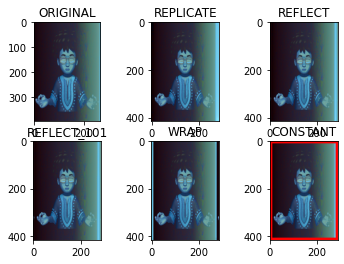

In [201]:
from matplotlib import pyplot as plt
BLUE = [255,0,0]
replicate = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_REPLICATE)
reflect = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_REFLECT_101)
wrap = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_WRAP)
constant= cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_CONSTANT,value=BLUE)
plt.subplot(231),plt.imshow(dest_img,'gray'),plt.title('ORIGINAL')
plt.subplot(232),plt.imshow(replicate,'gray'),plt.title('REPLICATE')
plt.subplot(233),plt.imshow(reflect,'gray'),plt.title('REFLECT')
plt.subplot(234),plt.imshow(reflect101,'gray'),plt.title('REFLECT_101')
plt.subplot(235),plt.imshow(wrap,'gray'),plt.title('WRAP')
plt.subplot(236),plt.imshow(constant,'gray'),plt.title('CONSTANT')

(<AxesSubplot:title={'center':'padded'}>,
 Text(0.5, 1.0, 'padded'))

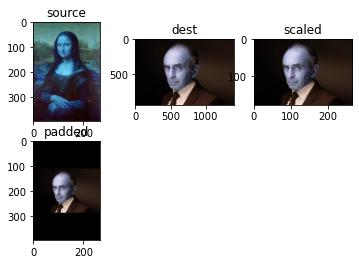

In [291]:
p1 = np.random.randint(0, 255, size=(3,4,3), dtype=np.uint8)
p2 = np.random.randint(0, 255, size=(5,5,3), dtype=np.uint8)

height, width = src_img_height, src_img_width
h, w = photo.shape[0], photo.shape[1]

pad_bottom, pad_right = 0, 0
ratio = w / h

if h > height or w > width:
    # shrinking image algorithm
    interp = cv2.INTER_AREA
else:
    # stretching image algorithm
    interp = cv2.INTER_CUBIC

w = width
h = round(w / ratio)

if h > height:
    h = height
    w = round(h * ratio)
    
pad_top= abs(height - h)//2 + 1
pad_bottom = abs(height - h)//2
# pad_left = abs(width - w)
# pad_right = abs(width - w)


scaled_img = cv2.resize(photo, (w, h), interpolation=interp)
padded_img = cv2.copyMakeBorder(scaled_img,pad_top,pad_bottom,pad_left,pad_right,borderType=cv2.BORDER_CONSTANT,value=[0,0,0])

plt.subplot(231),plt.imshow(src_img,'gray'),plt.title('source')
plt.subplot(232),plt.imshow(photo,'gray'),plt.title('dest')
plt.subplot(233),plt.imshow(scaled_img,'gray'),plt.title('scaled')
plt.subplot(234),plt.imshow(padded_img,'gray'),plt.title('padded')

In [272]:
src_img_height, src_img_width

(396, 266)

In [276]:
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/zemmour/to_recreate/Eric-Zemmour-22-avril-2021-Paris_0 copy.jpeg"
print(photo_path)
photo = cv2.imread(photo_path)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/zemmour/to_recreate/Eric-Zemmour-22-avril-2021-Paris_0 copy.jpeg
